In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
tech= ['NVDA', 'AAPL','MSFT','INTC','TSLA']
finance = ['JPM', 'MA', 'BAC', 'MS', 'GS']
all_tickers= tech+finance

data = yf.download(all_tickers, start='2021-01-01', end="2026-01-01")
prices = data["Close"]

print(prices.shape) #shape gives dim of DF rows (trading days) and cols (stocks)
prices.head()

[*********************100%***********************]  10 of 10 completed

(1255, 10)


Ticker,AAPL,BAC,GS,INTC,JPM,MA,MS,MSFT,NVDA,TSLA
Date,,,,,,,,,,
2021-01-04,125.740845,26.327255,233.060974,44.902931,109.491562,340.579346,57.623318,207.956100,13.060794,243.256668
2021-01-05,127.295502,26.528896,238.276245,45.752720,110.087357,336.635712,58.601547,208.156769,13.350876,245.036667
2021-01-06,123.010513,28.185856,251.134125,46.195698,115.256569,336.761688,62.135017,202.759384,12.563803,251.993332
2021-01-07,127.208038,28.808313,256.498901,47.181076,119.041496,339.429749,63.197601,208.529282,13.290372,272.013336
2021-01-08,128.306000,28.519001,255.118134,46.692909,119.172943,343.300720,63.459000,209.799805,13.223389,293.339996


In [13]:
#log returns= ln(p(n)/p(n-1))

simple_returns= prices.pct_change().dropna()
log_returns = np.log(prices/prices.shift(1)).dropna()

print("Simple returns:")
print(simple_returns.head())
print("\nLog returns:")
print(log_returns.head())


Simple returns:
Ticker          AAPL       BAC        GS      INTC       JPM        MA  \
Date                                                                     
2021-01-05  0.012364  0.007659  0.022377  0.018925  0.005441 -0.011579   
2021-01-06 -0.033662  0.062459  0.053962  0.009682  0.046956  0.000374   
2021-01-07  0.034123  0.022084  0.021362  0.021331  0.032839  0.007923   
2021-01-08  0.008631 -0.010043 -0.005383 -0.010347  0.001104  0.011404   
2021-01-11 -0.023249  0.016600  0.012928 -0.002130  0.014924 -0.015967   

Ticker            MS      MSFT      NVDA      TSLA  
Date                                                
2021-01-05  0.016976  0.000965  0.022210  0.007317  
2021-01-06  0.060297 -0.025929 -0.058953  0.028390  
2021-01-07  0.017101  0.028457  0.057830  0.079447  
2021-01-08  0.004136  0.006093 -0.005040  0.078403  
2021-01-11  0.010764 -0.009699  0.025966 -0.078214  

Log returns:
Ticker          AAPL       BAC        GS      INTC       JPM        MA  \
Date  

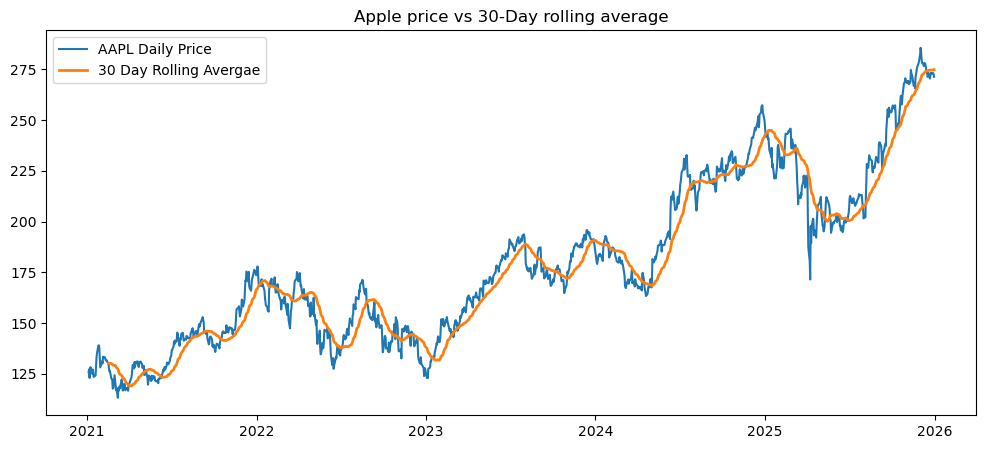

In [28]:
#rolling stats calculaates avergae or SD over a window of past days instead of whole history
# Rolling helps smooth out the noise

apple_price=prices["AAPL"]
rolling_30= apple_price.rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(apple_price, label="AAPL Daily Price")
plt.plot(rolling_30, label="30 Day Rolling Avergae", linewidth=2)
plt.title("Apple price vs 30-Day rolling average")
plt.legend()
plt.show()








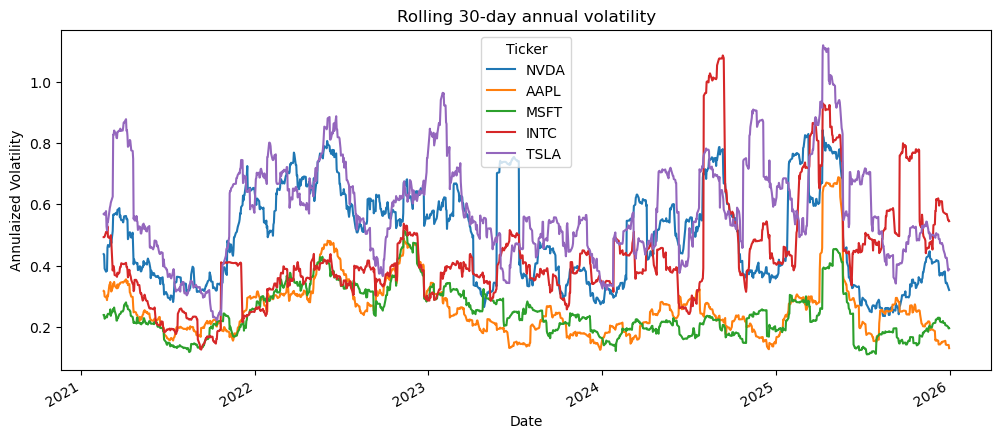

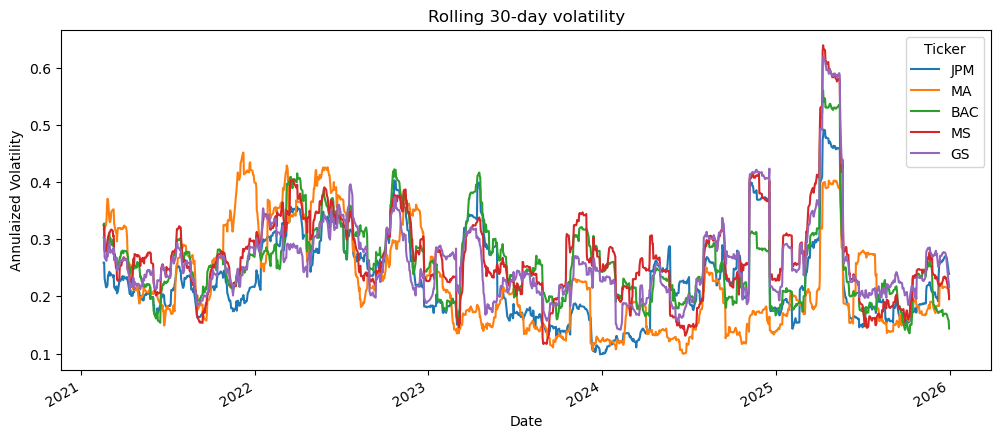

In [30]:
#np.sqrt(252) turns daily volatility to annualized volatility. 252 because theres roughly 252 trading days in a year

rolling_vol= log_returns.rolling(window=30).std()*np.sqrt(252)

rolling_vol[tech].plot(figsize=(12,5), title= "Rolling 30-day annual volatility")
plt.ylabel("Annulaized Volatility")
plt.show()

rolling_vol[finance].plot(figsize=(12,5), title="Rolling 30-day volatility")
plt.ylabel("Annulaized Volatility")
plt.show()

In [41]:
#Correlation Matrix. Near 1 is strong correlation, near 0 is weaker correlation

correlation_matrix_tech=log_returns[tech].corr()
print(correlation_matrix_tech)

correlation_matrix_fin=log_returns[finance].corr()
print("\n")
print(correlation_matrix_fin)

correlation_matrix=log_returns.corr()
print("\n")
print(correlation_matrix)

Ticker      NVDA      AAPL      MSFT      INTC      TSLA
Ticker                                                  
NVDA    1.000000  0.520711  0.631909  0.390007  0.472088
AAPL    0.520711  1.000000  0.633252  0.375324  0.500969
MSFT    0.631909  0.633252  1.000000  0.379760  0.423955
INTC    0.390007  0.375324  0.379760  1.000000  0.313460
TSLA    0.472088  0.500969  0.423955  0.313460  1.000000


Ticker       JPM        MA       BAC        MS        GS
Ticker                                                  
JPM     1.000000  0.478583  0.814334  0.740191  0.776422
MA      0.478583  1.000000  0.445156  0.491255  0.480677
BAC     0.814334  0.445156  1.000000  0.770055  0.763095
MS      0.740191  0.491255  0.770055  1.000000  0.841279
GS      0.776422  0.480677  0.763095  0.841279  1.000000


Ticker      AAPL       BAC        GS      INTC       JPM        MA        MS  \
Ticker                                                                         
AAPL    1.000000  0.345253  0.398884  

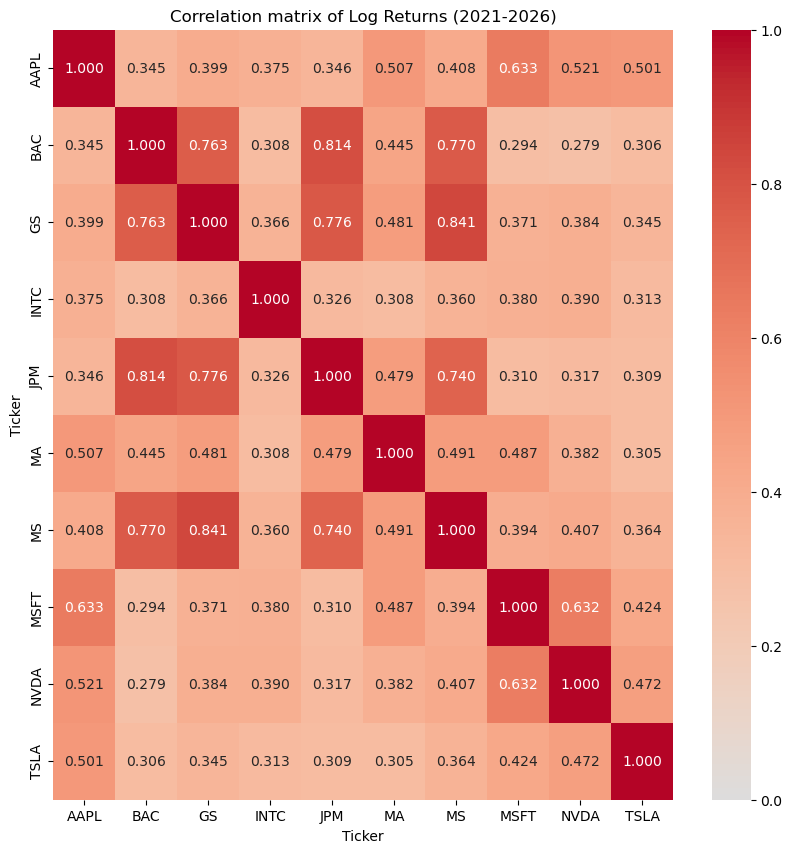

In [46]:
# Heat map to show correlation. Easier to read
#annot=True gives the actual correlation numbers in each square. fmt sets the decimal points of the numbers.

plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix,annot=True,fmt=".3f",cmap="coolwarm",center=0,vmin=0,vmax=1)
plt.title("Correlation matrix of Log Returns (2021-2026)")
plt.show()

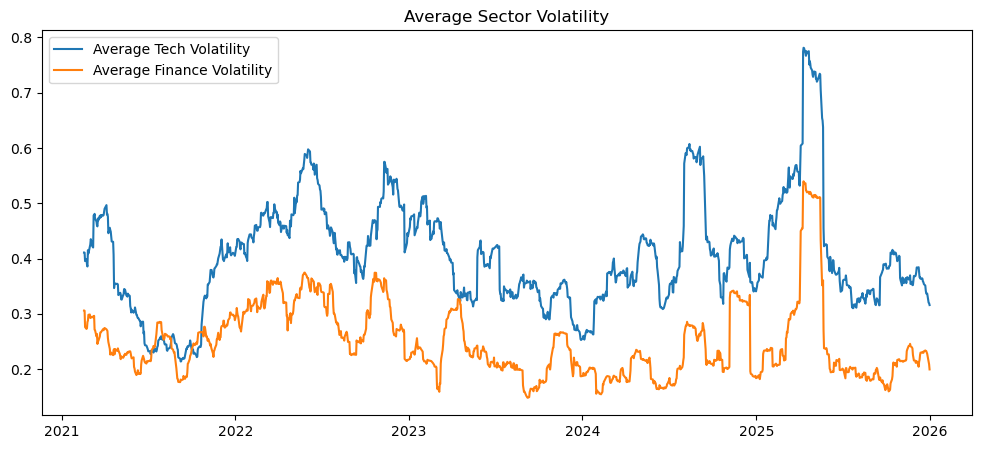

In [47]:
avg_tech_vol= rolling_vol[tech].mean(axis=1)
avg_fin_vol=rolling_vol[finance].mean(axis=1)

plt.figure(figsize=(12,5))
plt.plot(avg_tech_vol, label="Average Tech Volatility")
plt.plot(avg_fin_vol,label="Average Finance Volatility")
plt.title("Average Sector Volatility")
plt.legend()
plt.show()